In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/raw/investments_VC.csv",
    encoding="latin1"
)

df.columns = df.columns.str.strip()

In [3]:
df.columns.tolist()

['permalink',
 'name',
 'homepage_url',
 'category_list',
 'market',
 'funding_total_usd',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

## Business Question

How has startup creation changed over time?

### Why This Matters

Analyzing startup formation trends helps identify periods of rapid entrepreneurial growth and changes in startup ecosystem activity.

In [4]:
year_counts = (
    df["founded_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts.tail()

founded_year
2010    3773
2011    4905
2012    5211
2013    4044
2014    1469
Name: count, dtype: int64

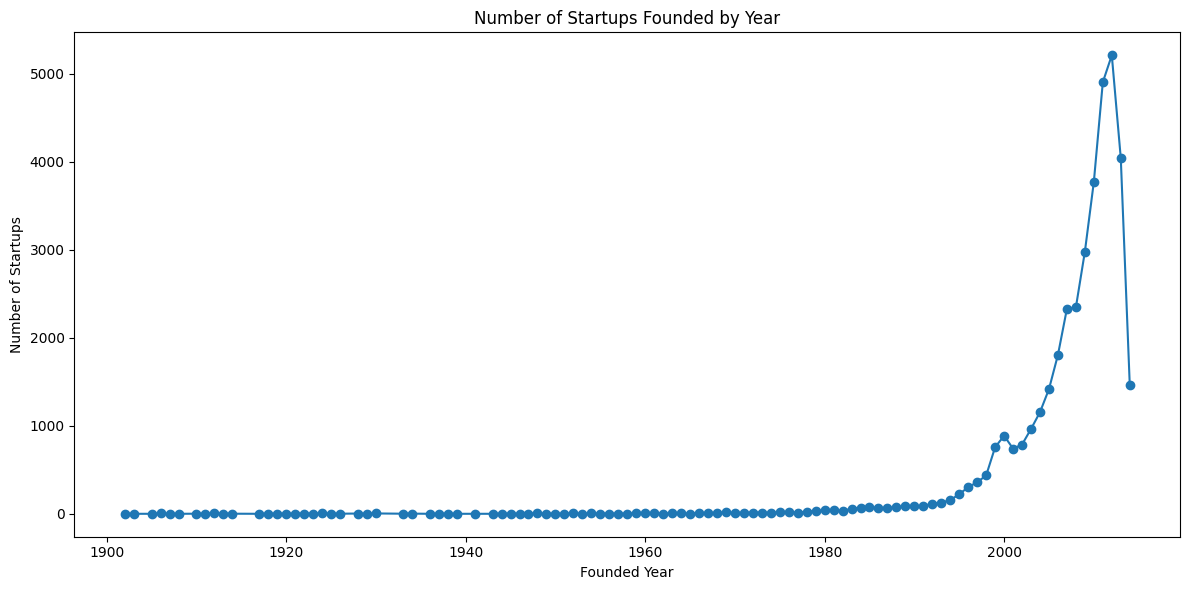

In [5]:
plt.figure(figsize=(12,6))

year_counts.plot(kind="line", marker="o")

plt.title("Number of Startups Founded by Year")
plt.xlabel("Founded Year")
plt.ylabel("Number of Startups")

plt.tight_layout()
plt.show()

## Key Insight: Startup Formation Trends Over Time

### Findings

- Startup creation remained relatively low throughout most of the 20th century.
- A significant increase began during the 1990s and accelerated after 2000.
- The highest number of startups in the dataset were founded between 2010 and 2013.
- Startup formation peaked in 2012 with more than 5,000 startups.

### Interpretation

The rapid growth after 2000 reflects the expansion of internet technologies, venture capital investment, cloud computing, and digital entrepreneurship.

The apparent decline after 2013 is likely caused by incomplete data collection rather than a true reduction in startup activity.

### Conclusion

Startup activity experienced exponential growth during the 21st century, with the early 2010s representing the most active period for startup creation in the dataset.

## Business Question

How has startup funding evolved over time?

### Why This Matters

Funding trends help reveal periods of strong investor confidence and rapid startup ecosystem growth.

In [7]:
df["funding_total_usd"] = (
    df["funding_total_usd"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("-", "", regex=False)
    .str.strip()
)

df["funding_total_usd"] = pd.to_numeric(
    df["funding_total_usd"],
    errors="coerce"
)

In [8]:
df["funding_total_usd"].dtype

dtype('float64')

In [11]:
year_funding = (
    df.groupby("founded_year")["funding_total_usd"]
    .sum()
    .sort_index()
)

year_funding.tail()

founded_year
2010.0    2.839501e+10
2011.0    2.503891e+10
2012.0    1.973232e+10
2013.0    9.074411e+09
2014.0    1.893958e+09
Name: funding_total_usd, dtype: float64

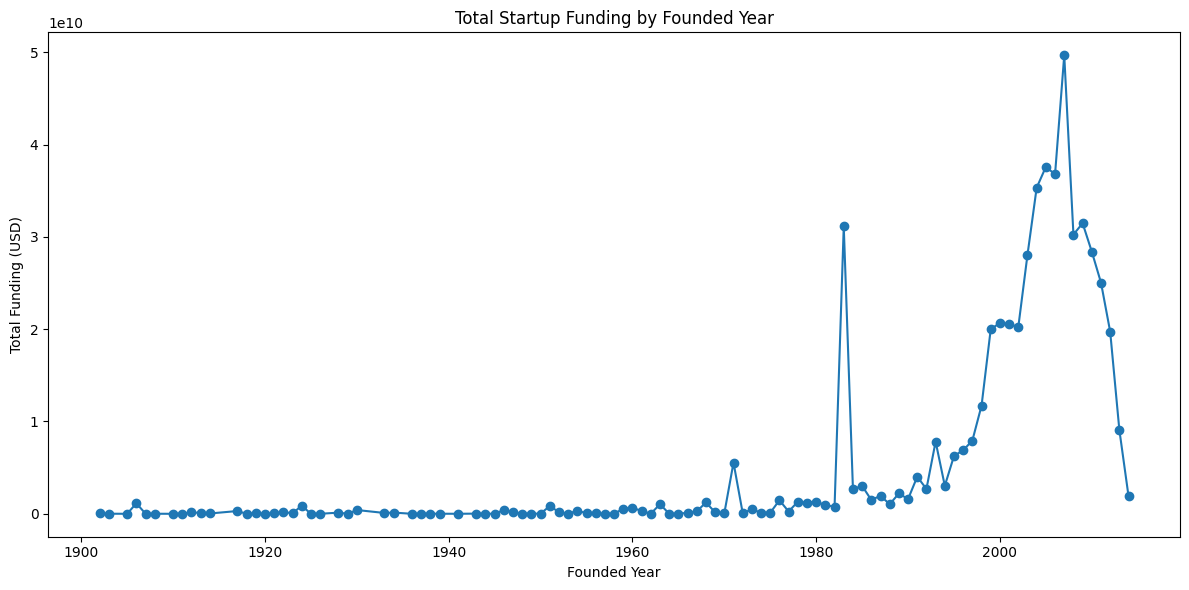

In [12]:
plt.figure(figsize=(12,6))

year_funding.plot(kind="line", marker="o")

plt.title("Total Startup Funding by Founded Year")
plt.xlabel("Founded Year")
plt.ylabel("Total Funding (USD)")

plt.tight_layout()
plt.show()

Note: The decline observed after 2012 is likely due to incomplete records in the dataset's final years rather than an actual decrease in startup activity.

Which markets grew the fastest over time?

In [13]:
top_markets = (
    df["market"]
    .value_counts()
    .head(5)
    .index
)

market_trends = (
    df[df["market"].isin(top_markets)]
    .groupby(["founded_year", "market"])
    .size()
    .unstack()
)

market_trends.tail()

market,Biotechnology,Curated Web,E-Commerce,Mobile,Software
founded_year,,,,,
2010.0,197.0,162.0,171.0,179.0,309.0
2011.0,180.0,201.0,246.0,283.0,383.0
2012.0,155.0,205.0,288.0,266.0,418.0
2013.0,92.0,86.0,192.0,149.0,282.0
2014.0,9.0,13.0,21.0,27.0,72.0


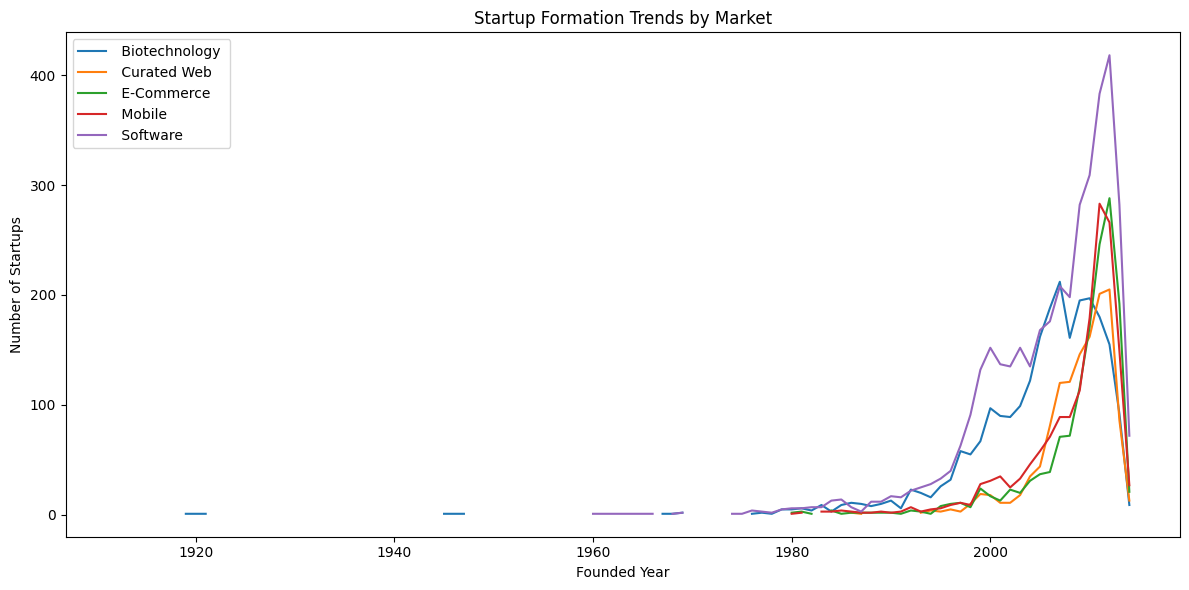

In [14]:
plt.figure(figsize=(12,6))

for col in market_trends.columns:
    plt.plot(
        market_trends.index,
        market_trends[col],
        label=col
    )

plt.title("Startup Formation Trends by Market")
plt.xlabel("Founded Year")
plt.ylabel("Number of Startups")

plt.legend()
plt.tight_layout()
plt.show()

Acquisitions Over Time

In [15]:
acquisition_trend = (
    df[df["status"] == "acquired"]
    .groupby("founded_year")
    .size()
)

acquisition_trend.tail()

founded_year
2010.0    208
2011.0    191
2012.0    108
2013.0     24
2014.0      1
dtype: int64

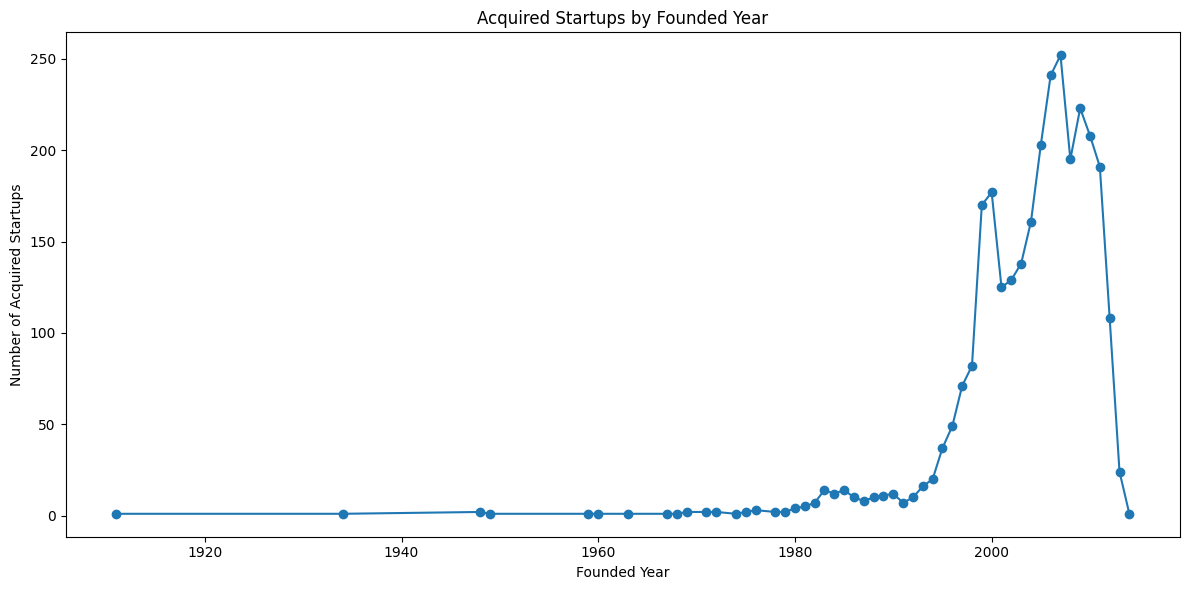

In [16]:
plt.figure(figsize=(12,6))

acquisition_trend.plot(kind="line", marker="o")

plt.title("Acquired Startups by Founded Year")
plt.xlabel("Founded Year")
plt.ylabel("Number of Acquired Startups")

plt.tight_layout()
plt.show()

# Final Conclusions

- Startup creation accelerated rapidly after 2000.
- The early 2010s represent the most active startup period in the dataset.
- Technology-driven industries experienced the strongest growth.
- Startup acquisitions increased alongside ecosystem growth.
- The apparent decline after 2013 is likely due to incomplete records in the dataset.